# Encode an LDPC Code

This code is provided as supplementary material of the lecture Channel Coding - Graph-based Codes.

This code illustrates
* Rearranging the parity-check matrix of an LDPC code according to the method provided in T. Richardson, R. Urbanke, "Efficient encoding of low density parity check codes," _IEEE Transactions on Information Theory_, vol. 47, no. 2, Feb. 2001
* Illustrate encoding by means of an example

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys

# Load the function to generate regular H matrices from the previous chapter.
sys.path.append('../ch5_LDPC_Finite_Length/')
from ipynb.fs.defs.getRegularH import getRegularH

Helper function that returns the inverse of a binary matrix using simple Gaussian elimination

In [2]:
# helper
def gf2_inv(A):
    """Return inverse of binary matrix A over GF(2). A must be square ndarray of 0/1."""
    A = A.copy() % 2
    n = A.shape[0]
    I = np.eye(n, dtype=int)
    M = np.concatenate([A, I], axis=1).astype(int)
    r = 0
    for c in range(n):
        # find pivot
        piv = np.where(M[r:, c] == 1)[0]
        if piv.size == 0:
            raise np.linalg.LinAlgError("Matrix not invertible over GF(2)")
        piv = piv[0] + r
        if piv != r:
            M[[r, piv]] = M[[piv, r]]
        # eliminate
        for i in range(n):
            if i != r and M[i, c] == 1:
                M[i] ^= M[r]
        r += 1
        if r == n:
            break
    return M[:, n:] % 2

Helper function that returns the inverse of an upper diagonal matrix $\boldsymbol{T}$ exploiting the fact that
\begin{equation*}
\boldsymbol{T}^{-1} = \begin{pmatrix} \boldsymbol{T}_{11} &  \boldsymbol{T}_{12} \\ \boldsymbol{0} & \boldsymbol{T}_{22}\end{pmatrix}^{-1}  = \begin{pmatrix}  \boldsymbol{T}_{11}^{-1} & \boldsymbol{T}_{11}^{-1}\boldsymbol{T}_{12}\boldsymbol{T}_{22}^{-1} \\ \boldsymbol{0} & \boldsymbol{T}_{22}^{-1}\end{pmatrix}
\end{equation*}
and by using recursively that $\boldsymbol{T}_{ii}$ are themselves upper diagonal matrices. We partition $\boldsymbol{T}$ into submatrices $\boldsymbol{T}_{ij}$ of approximately equal size and then invoke the function recursively to compute $\boldsymbol{T}_{ii}^{-1}$. If the input matrix has less than 5 rows, we use pure Gaussian elimination to compute the inverse, as it is sufficiently fast.

In [3]:
def invert_upper_diagonal(T):
    T = np.array(T, dtype=int) % 2

    if T.shape[0] < 5:
        return gf2_inv(T)
    else:
        sht1 = int(np.ceil(T.shape[0] / 2))
        sht2 = T.shape[0] - sht1
        T11 = T[:sht1, :sht1]
        T22 = T[sht1:, sht1:]
        T12 = T[:sht1, sht1:]

        T11i = invert_upper_diagonal(T11)
        T22i = invert_upper_diagonal(T22)

        Tz = np.zeros((sht2, sht1), dtype=int)
        Tur = (T11i @ T12 @ T22i) % 2
        Ti = np.block([[T11i, Tur], [Tz, T22i]]) % 2

        return Ti

In [4]:
def greedy_lower_triangulate_forenc(H):
    """Try to find a lower triangular form of H by greedily swapping columns. Returns T,A,B,E,C,D, colintl."""

    H = np.array(H, dtype=int) % 2

    resdegrees = np.array(np.sum(H, axis=0), dtype=int)
    resdegrees[resdegrees==0] = 9999

In [8]:
def greedy_upper_triangulate_forenc(H):
    """
    carries out greedy upper triangulation as described in Appendix A.2 of Richardson, Urbanke, "Modern Coding Theory"
    """
    rng = np.random.default_rng()
    
    H = np.array(H, dtype=int) % 2

    resdegrees = np.array(np.sum(H, axis=0), dtype=int)
    resdegrees[resdegrees==0] = 9999
    n = H.shape[1]
    k = n - H.shape[0]

    Hg = H.copy()
    t = 0
    g = 0

    colintl = np.arange(n, dtype=int)
    while t != n-g-k:
        # EXTEND
        idx = np.where(resdegrees==np.min(resdegrees))[0]
        rancol = idx[rng.integers(idx.size)]
        rs = np.where(Hg[:, rancol])[0]
        rs = rs[(rs >= t) & (rs < n - k - g)]
        Hg[:, [t, rancol]] = Hg[:, [rancol, t]]
        Hg[[t,rs[0]], :] = Hg[[rs[0], t], :]

        colintl[[t, rancol]] = colintl[[rancol, t]]

        t += 1
        if np.min(resdegrees) != 1:
            # CHOOSE
            # increase gap
            for i in range(1, rs.size):
                r1 = rs[i]
                r2 = n - k - g - (i - 1) - 1
                Hg[[r1, r2], :] = Hg[[r2, r1], :] 
            g += rs.size - 1
        
        # update residual degrees
        resdegrees = np.sum(Hg[t:n-g-k], axis=0, dtype=int)
        resdegrees[:t] = 9999
        resdegrees[resdegrees==0] = 9999
    
    Ts = H.shape[0] - g
    T = Hg[:Ts,:Ts]
    A = Hg[:Ts,Ts:Ts+g]
    B = Hg[:Ts, Ts+g:]
    E = Hg[Ts:,:Ts]
    C = Hg[Ts:, Ts:Ts+g]
    D = Hg[Ts:, Ts+g:]

    return T, A, B, E, C, D, colintl

### Example illustrating the different stages of the parity-check matrix preprocessing

Generate a code:

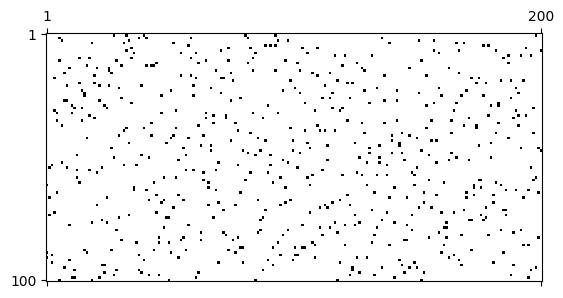

In [9]:
# Regular LDPC code with n = 200 variable nodes, dv = 3, dc = 6
H = getRegularH(200,3,6)

# display the parity-check matrix
plt.spy(H)
m, n = H.shape

plt.xticks([0, n-1], [1, n])
plt.yticks([0, m-1], [1, m])
plt.show()

We next invoke the greedy upper triangulation algorithm as described in Appendix A.2 of Richardson, Urbanke, _Modern Coding Theory_ . 

dim(T) = 95 x 95
dim(A) = 95 x 5
dim(B) = 95 x 100
dim(E) = 5 x 95
dim(C) = 5 x 5
dim(D) = 5 x 100
Gap g = 5


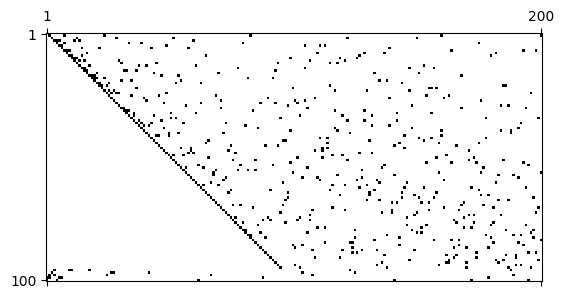

In [10]:
T, A, B, E, C, D, colintl = greedy_upper_triangulate_forenc(H)
print ("dim(T) = %d x %d" % (T.shape[0], T.shape[1]))
print ("dim(A) = %d x %d" % (A.shape[0], A.shape[1]))
print ("dim(B) = %d x %d" % (B.shape[0], B.shape[1]))
print ("dim(E) = %d x %d" % (E.shape[0], E.shape[1]))
print ("dim(C) = %d x %d" % (C.shape[0], C.shape[1]))
print ("dim(D) = %d x %d" % (D.shape[0], D.shape[1]))

print("Gap g = %d" % C.shape[0])

Ht = np.block([[T, A, B], [E, C, D]]) % 2

plt.spy(Ht)
m, n = Ht.shape

plt.xticks([0, n-1], [1, n])
plt.yticks([0, m-1], [1, m])
plt.show()

In [11]:
# Invert T
Ti = invert_upper_diagonal(T)

In [16]:

def Encode_LDPC(H, u):
    """
    H is parity check matrix
    u is input vector
    x is output vector
    """
    rng = np.random.default_rng()
    
    # _encoder_cache is an internal attribute of the function to store previously computed encoders for different H matrices. This is a simple form of memorization to speed up encoding when the same H matrix is used multiple times.
    if not hasattr(Encode_LDPC, "_encoder_cache"):
        Encode_LDPC._encoder_cache = {}

    H = np.array(H, dtype=int) % 2
    key = H.tobytes()

    if key not in Encode_LDPC._encoder_cache:
        for _ in range(200):

            T, A, B, E, C, D, colintl = greedy_upper_triangulate_forenc(H)

            try:
                Ti = invert_upper_diagonal(T)
            except Exception:
                continue

            temp = (E @ Ti) % 2

            # fix phi
            for _ in range(200):

                phi = (C + temp @ A) % 2

                try:
                    phi_inv = gf2_inv(phi)
                    break
                except Exception:
                    if A.shape[1] == 0 or B.shape[1] == 0:
                        break

                    # swap columns
                    rc1 = rng.integers(A.shape[1])
                    rc2 = rng.integers(B.shape[1])
                    A[:, rc1], B[:, rc2] = B[:, rc2].copy(), A[:, rc1].copy()
                    C[:, rc1], D[:, rc2] = D[:, rc2].copy(), C[:, rc1].copy()
                    idx1 = E.shape[1] + rc1
                    idx2 = E.shape[1] + A.shape[1] + rc2
                    colintl[[idx1, idx2]] = colintl[[idx2, idx1]]

            else:
                continue 

            Encode_LDPC._encoder_cache[key] = (T,A,B,E,C,D,Ti,phi_inv,colintl)
            break

        else:
            raise RuntimeError("Failed to build encoder")

    T,A,B,E,C,D,Ti,phi_inv,colintl = Encode_LDPC._encoder_cache[key]

    u = np.array(u, dtype=int).reshape(-1, 1) % 2

    p2 = (phi_inv @ ((D + E @ Ti @ B) % 2) @ u) % 2
    p1 = (Ti @ ((A @ p2 + B @ u) % 2)) % 2

    x = np.vstack([p1, p2, u])
    x = np.array(x).astype(int).flatten()

    x_perm = np.empty_like(x)
    x_perm[colintl] = x

    return x_perm


### Test

In [15]:
H = getRegularH(200,3,6)
u = np.random.randint(0,2, H.shape[1] - H.shape[0])
x = Encode_LDPC(H, u)

print("Codeword check fulfilled (zero syndrome):", np.all((np.array(H) @ x) % 2 == 0))

Codeword check fulfilled (zero syndrome): True
